In [ ]:
Profile the baseline algorithm

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:

def equal_step_baseline_py(imStack):
    """
    Python baseline version of equalStep_baseline.

    Parameters
    ----------
    imStack : np.ndarray
        Shape = (NSTEPS, M, N)
        dtype ideally uint16

    Returns
    -------
    wrappedPhase : np.ndarray
        Shape = (M, N), dtype=float64
    mod : np.ndarray
        Shape = (M, N), dtype=float64
    """
    NSTEPS, M, N = imStack.shape

    wrappedPhase = np.zeros((M, N), dtype=np.float64)
    mod = np.zeros((M, N), dtype=np.float64)
    phi_t1_buf = np.zeros((M, N), dtype=np.float64)
    phi_t2_buf = np.zeros((M, N), dtype=np.float64)

    timing = {
        "precompute_trig" : 0.0,
        "accumulation" : 0.0,
        "atan2" : 0.0,
        "sqrt" : 0.0,
        "total": 0.0,
    }
    
    sin_k = np.zeros(NSTEPS, dtype=np.float64)
    cos_k = np.zeros(NSTEPS, dtype=np.float64)

    t0 = time.perf_counter()
    # precompute sin and cos values
    for k in range(NSTEPS):
        sin_k[k] = math.sin(2*math.pi *k / NSTEPS)
        cos_k[k] = math.cos(2*math.pi *k / NSTEPS)
        
    timing["precompute_trig"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    
    for i in range(M):
        for j in range(N):
            Phi_t1 = 0.0
            Phi_t2 = 0.0
            
            for k in range(NSTEPS):
                val = float(imStack[k, i, j])
                Phi_t1 += val * sin_k[k]
                Phi_t2 += val * cos_k[k]
            phi_t1_buf[i, j] = Phi_t1
            phi_t2_buf[i, j] = Phi_t2
    timing["accumulation"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    
    for i in range(M):
        for j in range(N):
            wrappedPhase[i, j] = math.atan2(phi_t1_buf[i, j], phi_t2_buf[i, j])
            
    timing["atan2"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    for i in range(M):
        for j in range(N):
            mod[i, j] = math.sqrt(phi_t1_buf[i, j] * phi_t1_buf[i, j] +
                                  phi_t2_buf[i, j] * phi_t2_buf[i, j])
    timing["sqrt"] = time.perf_counter() - t0

    return wrappedPhase, mod, timing
    


In [3]:
#Load image stack, ground truth values

from PIL import Image
import os

def load_stack(dataset_id, base_path):
    """
    Loads stack_k_0.png ... stack_k_4.png into a NumPy array.

    Returns:
        imStack: (NSTEPS, M, N) uint16
    """
    images = []

    for step in range(5):
        filename = os.path.join(base_path, f"stack_{dataset_id}_{step}.png")

        img = Image.open(filename)
        img_np = np.array(img)

        # ensure uint16
        if img_np.dtype != np.uint16:
            img_np = img_np.astype(np.uint16)

        images.append(img_np)

    imStack = np.stack(images, axis=0)

    return imStack

# Load ground truth phi & mod
def load_ground_truth(dataset_id, base_path):
    phi = np.loadtxt(os.path.join(base_path, f"phi_{dataset_id}.csv"), delimiter=",")
    mod = np.loadtxt(os.path.join(base_path, f"mod_{dataset_id}.csv"), delimiter=",")

    return phi, mod

In [4]:
# Run baseline, ensure correct output
base_path = "TestData_small"

dataset_id = 0

imStack = load_stack(dataset_id, base_path)
phi_gt, mod_gt = load_ground_truth(dataset_id, base_path)

phi_pred, mod_pred, timing = equal_step_baseline_py(imStack)

print("Shapes:", imStack.shape, phi_gt.shape)

print("Phase error (max):", np.max(np.abs(phi_pred - phi_gt)))
print("Mod error (max):", np.max(np.abs(mod_pred - mod_gt)))

for k,v in timing.items():
    print(f"{k:16s}: {v:.10f}")

Shapes: (5, 64, 64) (64, 64)
Phase error (max): 4.718447854656915e-16
Mod error (max): 5.115907697472721e-13
precompute_trig : 0.0000094000
accumulation    : 0.0062416000
atan2           : 0.0007681000
sqrt            : 0.0014476000
total           : 0.0000000000


In [5]:
#Repeat timing multiple times
runs = 5
timings = []

for _ in range(runs):
    _, _, timing = equal_step_baseline_py(imStack)
    timings.append(timing)

df = pd.DataFrame(timings)
df.mean()

precompute_trig    0.000003
accumulation       0.006286
atan2              0.000796
sqrt               0.001591
total              0.000000
dtype: float64

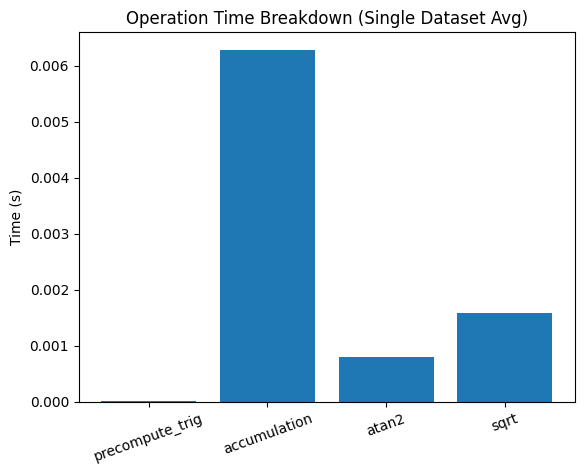

In [6]:
#plot
avg = df.mean()

plt.bar(avg.index[:-1], avg.values[:-1])  # exclude total if you want
plt.title("Operation Time Breakdown (Single Dataset Avg)")
plt.ylabel("Time (s)")
plt.xticks(rotation=20)
plt.show()


In [8]:
test_imStack = np.random.randint(
    0, 65535,
    size=(5, 1080, 1920),
    dtype=np.uint16
)

t0 = time.perf_counter()
phi_pred, mod_pred, timing = equal_step_baseline_py(test_imStack)
elapsed = time.perf_counter() - t0

print("Overall elapsed time:", elapsed)
print("Breakdown:")
for k, v in timing.items():
    print(f"{k:16s}: {v:.6f} s")


Overall elapsed time: 4.532296800003678
Breakdown:
precompute_trig : 0.000009 s
accumulation    : 3.263509 s
atan2           : 0.449257 s
sqrt            : 0.818458 s
total           : 0.000000 s
